In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [31]:
def linear(x, w, b):
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    return np.dot(x, w) + b

In [29]:
def activation(z):
    return np.maximum(0 ,z) #try 0.01 and 0.001 for leaky relu

In [30]:
def backprop(x, y, y_pred, z1, a1, w2):
    N = len(x)
    dL_dy_pred = 2.0 * (y_pred - y) / N  # Average gradient

    dw2 = np.dot(a1.T, dL_dy_pred)        # Do NOT divide by N again here
    db2 = np.sum(dL_dy_pred, axis=0, keepdims=True)

    dL_da1 = np.dot(dL_dy_pred, w2.T)
    dL_dz1 = dL_da1 * (z1 > 0)

    dw1 = np.dot(x.T, dL_dz1)             # Do NOT divide by N again here
    db1 = np.sum(dL_dz1, axis=0, keepdims=True)
    
    return dw1, db1, dw2, db2

In [5]:
def init():
    w1 = np.random.randn(1, 50) * np.sqrt(2.0 / 1)
    b1 = np.zeros((1, 50))

    w2 = np.random.randn(50, 1) * np.sqrt(2.0 / 50)
    b2 = np.zeros((1, 1))
    
    return w1, b1, w2, b2

In [8]:
def model_train_k1(x, y):
    learning_rate = 0.001
    x = np.array(x, dtype=np.float64).reshape(-1, 1)
    y = np.array(y, dtype=np.float64).reshape(-1, 1)
    w1, b1, w2, b2 = init()
    if y.ndim == 1: y = y.reshape(-1, 1)
    for i in range(10000):
        # Forward Pass
        z1 = linear(x, w1, b1)
        a1 = np.maximum(0, z1)
        y_pred = linear(a1, w2, b2)
        loss = np.mean((y - y_pred) ** 2)
        print("Loss is", loss)
        # Backpropagation
        dw1, db1, dw2, db2 = backprop(x, y, y_pred, z1, a1, w2)
        # Updates
        w1 -= learning_rate * dw1
        b1 -= learning_rate * db1
        w2 -= learning_rate * dw2
        b2 -= learning_rate * db2
    return w1, b1, w2, b2

In [6]:
step = 0.001
iter = 20001
start = -10
end = 1
x_data = np.array([])
y_data = np.array([])
for i in range(iter):
    x_data = np.append(x_data, [start])
    y_data = np.append(y_data, [np.square(start)])
    start = start + step
x_data = x_data.reshape(-1, 1)
y_data = y_data.reshape(-1, 1)
#NO QAT
#trained_w1, trained_b1, trained_w2, trained_b2 = model_train_k1(x_data, y_data)

## POST TRAINING QUANTIZATION

In [25]:
def scale_quant(r, S, Z, qmin, qmax):
    return np.clip(np.round(r/S)+Z, qmin, qmax)

def pt_quantization(trained_w1, trained_b1, trained_w2, trained_b2, bitlength):
    rmax = max(np.max(trained_w1), np.max(trained_b1), np.max(trained_w2), np.max(trained_b2))
    rmin = min(np.min(trained_w1), np.min(trained_b1), np.min(trained_w2), np.min(trained_b2))
    qmax = ((1<<(bitlength-1)))-1
    qmin = -qmax - 1
    S = (rmax-rmin)/(qmax-qmin)
    Z = np.round(qmin-rmin/S)
    quant_w1 = scale_quant(trained_w1, S, Z, qmin, qmax)
    quant_b1 = scale_quant(trained_b1, S, Z, qmin, qmax)
    quant_w2 = scale_quant(trained_w2, S, Z, qmin, qmax)
    quant_b2 = scale_quant(trained_b2, S, Z, qmin, qmax)
    return quant_w1, quant_b1, quant_w2, quant_b2, S, Z

def input_quantization(w1, b1, bitlength, x_data, S_w, Z_w):
    x_new = np.array(x_data, dtype=np.float64).reshape(-1, 1)
    dequant_w1 = S_w * (w1 - Z_w)
    dequant_b1 = S_w * (b1 - Z_w)
    a1 = activation(linear(x_new, dequant_w1, dequant_b1))
    rmax = np.max(a1)
    rmin = np.min(a1)
    qmax = (1<<(bitlength-1)) - 1
    qmin = -qmax -1
    S = (rmax-rmin)/(qmax-qmin)
    Z = np.round(qmin-rmin/S)
    return S, Z, qmin, qmax

def quantize_k(trained_w1, trained_b1, trained_w2, trained_b2, bitlength, x_data):
    quant_w1, quant_b1, quant_w2, quant_b2, S_w, Z_w = pt_quantization(trained_w1, trained_b1, trained_w2, trained_b2, bitlength)
    
    sample_size = max(1, int(len(x_data) * 0.10))
    random_indices = np.random.choice(len(x_data), size=sample_size, replace=False)
    x_sample = x_data[random_indices].reshape(-1, 1)
    
    S, Z, qmin, qmax = input_quantization(quant_w1, quant_b1, bitlength, x_sample, S_w, Z_w)
    return quant_w1, quant_b1, quant_w2, quant_b2, S_w, Z_w, qmin, qmax

def CLE(trained_w1, trained_b1, trained_w2):
    r1 = np.abs(trained_w1)
    r2 = np.abs(trained_w2).reshape(r1.shape)
    s = np.sqrt(r2/r1+1e-8)
    return trained_w1*s, trained_b1*s, trained_w2/s.reshape(trained_w2.shape)

## QUANTIZATION AWARE TRAINING

In [7]:
def quantize_asymmetric(x, bits=8):
    qmin = 0
    qmax = 2**bits - 1
    min_val = np.min(x)
    max_val = np.max(x)
    if min_val == max_val:
        scale = 1.0
        zp = 0
    else:
        scale = (max_val - min_val) / (qmax - qmin)
        zp = np.round(-min_val / scale)
        zp = np.clip(zp, qmin, qmax)
    q_x = np.round(x / scale + zp)
    q_x = np.clip(q_x, qmin, qmax)
    dq_x = scale * (q_x - zp)
    return dq_x

def quantize_symmetric(w, bits=8):
    qmax = 2**(bits - 1) - 1
    max_val = np.max(np.abs(w))
    if max_val == 0:
        scale = 1.0
    else:
        scale = max_val / qmax
    q_w = np.round(w / scale)
    q_w = np.clip(q_w, -qmax, qmax)
    dq_w = scale * q_w
    return dq_w
def linear_qat(x, w, b, bits=8):
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    x_q = quantize_asymmetric(x, bits=bits)
    w_q = quantize_symmetric(w, bits=bits)
    
    return np.dot(x_q, w_q) + b, x_q, w_q

def backprop_qat(x_q, y, y_pred, z1, a1_q, w2_q):
    N = len(x_q)
    dL_dy_pred = 2.0 * (y_pred - y) / N

    dw2 = np.dot(a1_q.T, dL_dy_pred)
    db2 = np.sum(dL_dy_pred, axis=0, keepdims=True)

    dL_da1 = np.dot(dL_dy_pred, w2_q.T)
    dL_dz1 = dL_da1 * (z1 > 0)

    dw1 = np.dot(x_q.T, dL_dz1)
    db1 = np.sum(dL_dz1, axis=0, keepdims=True)
    
    return dw1, db1, dw2, db2

def model_train_qat(x, y, epochs, learning_rate, bits=8):
    x = np.array(x, dtype=np.float64).reshape(-1, 1)
    y = np.array(y, dtype=np.float64).reshape(-1, 1)
    
    w1, b1, w2, b2 = init()
    
    for i in range(epochs):
        z1, x_q, w1_q = linear_qat(x, w1, b1, bits=bits)
        a1 = np.maximum(0, z1)
        
        a1_q = quantize_asymmetric(a1, bits=bits)
        y_pred, a1_q, w2_q = linear_qat(a1_q, w2, b2, bits=bits)
        
        loss = np.mean((y - y_pred) ** 2)
        if i % 1000 == 0:
            print(f"Epoch {i}, QAT Loss: {loss:.4f}")
            
        dw1, db1, dw2, db2 = backprop_qat(x_q, y, y_pred, z1, a1_q, w2_q)
        
        w1 -= learning_rate * dw1
        b1 -= learning_rate * db1
        w2 -= learning_rate * dw2
        b2 -= learning_rate * db2
        
    return w1, b1, w2, b2

In [43]:
import numpy as np

def export_qat_weights(trained_w1, trained_b1, trained_w2, trained_b2, bitlength):
    """
    Converts trained QAT float weights into actual INT8/INT-X arrays
    using per-layer symmetric quantization.
    """
    def quantize_weight_layer(w, bits):
        qmax = (1 << (bits - 1)) - 1  # e.g., 127 for 8-bit
        max_val = np.max(np.abs(w))
        
        # Calculate per-layer scale
        S = 1.0 if max_val == 0 else max_val / qmax
        
        # Quantize and clip
        q_w = np.round(w / S)
        q_w = np.clip(q_w, -qmax, qmax)
        
        # Cast directly to integer numpy array
        return q_w.astype(np.int8), S

    quant_w1, S_w1 = quantize_weight_layer(trained_w1, bitlength)
    quant_w2, S_w2 = quantize_weight_layer(trained_w2, bitlength)
    quant_b1, S_b1 = quantize_weight_layer(trained_b1, bitlength)
    quant_b2, S_b2 = quantize_weight_layer(trained_b2, bitlength)
    
    return quant_w1, quant_b1, quant_w2, quant_b2, S_w1, S_b1, S_w2, S_b2

In [44]:
epochs = 10000
learning_rate = 0.001
#trained_w1, trained_b1, trained_w2, trained_b2 = model_train_qat(x_data, y_data, epochs, learning_rate, 8)
qat_w1, qat_b1, qat_w2, qat_b2, S_w1, S_b1, S_w2, S_b2 = export_qat_weights(trained_w1, trained_b1, trained_w2, trained_b2, 8)

dq_w1 = qat_w1.astype(np.float64) * S_w1
dq_b1 = qat_b1.astype(np.float64) * S_b1
dq_w2 = qat_w2.astype(np.float64) * S_w2
dq_b2 = qat_b2.astype(np.float64) * S_b2

In [46]:
dq_w1

array([[-1.49565349, -0.77422063, -0.05278777,  1.67161273, -1.07335133,
        -0.70383694,  0.14076739,  0.87979617, -1.02056356,  0.75662471,
         0.        , -0.33432255,  0.45749401,  0.07038369,  1.14373502,
         0.12317146,  0.56306955,  1.61882496,  0.15836331, -0.40470624,
         0.15836331,  1.16133095, -0.91498802, -0.15836331, -1.02056356,
         0.70383694,  0.35191847,  0.33432255,  0.49268586,  0.5982614 ,
        -1.16133095,  0.03519185,  0.38711032,  0.68624101, -0.58066547,
        -0.43989809,  0.19355516, -0.93258394, -0.77422063, -1.00296764,
         1.10854318,  0.31672662, -1.98833935,  2.23468228,  0.26393885,
         0.45749401,  0.68624101, -1.23171464,  0.58066547,  0.2991307 ]])

In [47]:
def predict(x_new, w1, b1, w2, b2):
    x_new = np.array(x_new, dtype=np.float64).reshape(-1, 1)
    a1 = activation(linear(x_new, w1, b1))
    y_pred = linear(a1, w2, b2)
    return y_pred

Number of points retained: 32438
Total points tested: 100000


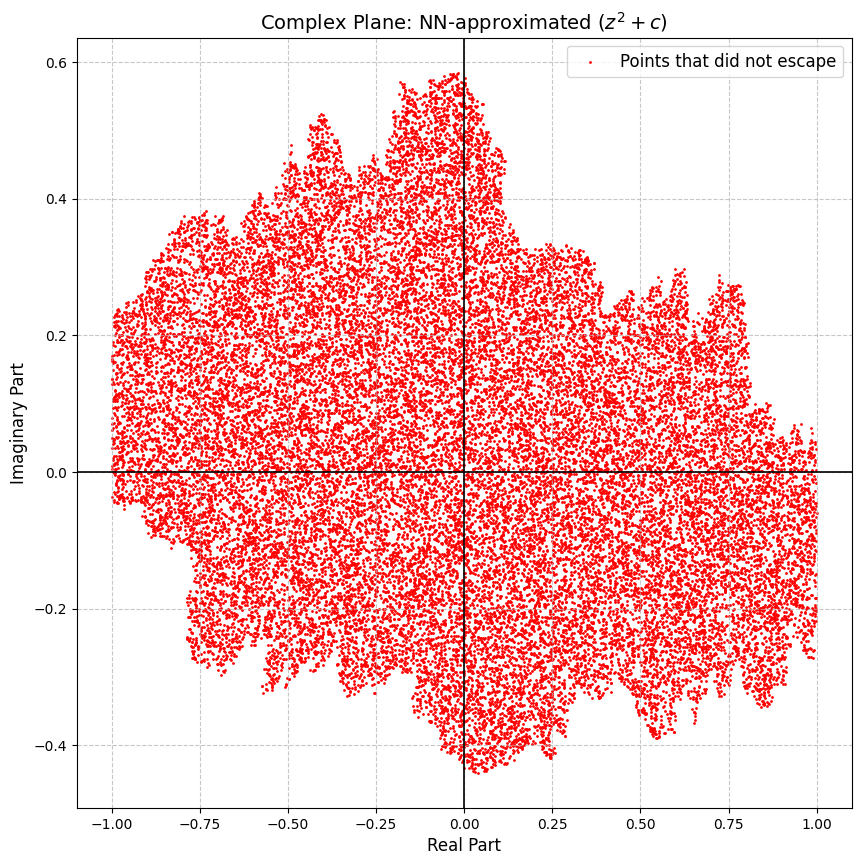

In [48]:
import numpy as np
import matplotlib.pyplot as plt

#YES QUANTIZE
#cle_w1, cle_b1, cle_w2 = CLE(trained_w1, trained_b1, trained_w2)
#quant_w1, quant_b1, quant_w2, quant_b2, S, Z, qmin, qmax = quantize_k(cle_w1, cle_b1, cle_w2, trained_b2, 8, x_data)
real_test = np.random.uniform(-1, 1, 100000)
imag_test = np.random.uniform(-1, 1, 100000)

n_iters = 25
bailout = 2.0

# c is now a single fixed constant for the whole set
c_real, c_imag = -0.8, 0.156   # classic dendrite-like Julia set

# z starts AT the sampled point instead of at 0
z_real = real_test.copy()
z_imag = imag_test.copy()
escaped = np.zeros(len(real_test), dtype=bool)
#dw1 = S * (quant_w1 - Z)
#db1 = S * (quant_b1 - Z)
#dw2 = S * (quant_w2 - Z)
#db2 = S * (quant_b2 - Z)

for i in range(n_iters):
    #YES QUANTIZE
    #zr_sq = predict(z_real, dw1, db1, dw2, db2).flatten()
    #zi_sq = predict(z_imag, dw1, db1, dw2, db2).flatten()
    
    #NO QUANTIZE
    zr_sq = predict(z_real, dq_w1, dq_b1, dq_w2, dq_b2).flatten()
    zi_sq = predict(z_imag, dq_w1, dq_b1, dq_w2, dq_b2).flatten()
    #zr_sq = z_real **2
    #zi_sq = z_imag **2

    new_real = zr_sq - zi_sq + c_real
    new_imag = 2 * z_real * z_imag + c_imag

    active = ~escaped
    z_real[active] = new_real[active]
    z_imag[active] = new_imag[active]

    mag = np.sqrt(z_real**2 + z_imag**2)
    newly_escaped = (~escaped) & (mag > bailout)
    escaped |= newly_escaped
    z_real[escaped] = bailout * 2
    z_imag[escaped] = bailout * 2

mask = ~escaped
x_filtered = np.column_stack((real_test, imag_test))[mask]

# Plotting on the Complex Plane
plt.figure(figsize=(10, 10))

plt.scatter(x_filtered[:, 0], x_filtered[:, 1], color='red', marker='o',
            label='Points that did not escape', s=1)

plt.xlabel('Real Part', fontsize=12)
plt.ylabel('Imaginary Part', fontsize=12)
plt.title('Complex Plane: NN-approximated ($z^2 + c$)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

print("Number of points retained:", len(x_filtered))
print("Total points tested:", len(real_test))

# Make axes pass through the origin for better visualization
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)

plt.show()

In [49]:
def escape_time_grid(c_real, c_imag, dw1, db1, dw2, db2,
                      xmin=-1.5, xmax=1.5, ymin=-1.5, ymax=1.5,
                      res=350, max_iter=40, bailout=2.0):
    """Escape-time grid for z -> z^2 + c, using the trained NN in place of
    literal squaring: (a+bi)^2 = (a^2 - b^2) + (2ab)i."""
    real_axis = np.linspace(xmin, xmax, res)
    imag_axis = np.linspace(ymin, ymax, res)
    real_grid, imag_grid = np.meshgrid(real_axis, imag_axis)

    z_real = real_grid.flatten().astype(np.float64)
    z_imag = imag_grid.flatten().astype(np.float64)

    escape_iter = np.full(z_real.shape, max_iter, dtype=np.float64)
    escaped = np.zeros(z_real.shape, dtype=bool)
    bailout_sq = bailout ** 2

    for i in range(max_iter):
        zr_sq = predict(z_real, dq_w1, dq_b1, dq_w2, dq_b2).flatten()
        zi_sq = predict(z_imag, dq_w1, dq_b1, dq_w2, dq_b2).flatten()

        new_real = zr_sq - zi_sq + c_real
        new_imag = 2 * z_real * z_imag + c_imag

        active = ~escaped
        z_real[active] = new_real[active]
        z_imag[active] = new_imag[active]

        mag_sq = z_real ** 2 + z_imag ** 2
        newly_escaped = (~escaped) & (mag_sq > bailout_sq)
        escape_iter[newly_escaped] = i
        escaped |= newly_escaped

        # freeze escaped points so they don't blow up / NaN later
        z_real[escaped] = bailout * 2
        z_imag[escaped] = bailout * 2

    return escape_iter.reshape(res, res)

In [50]:
# Sweep c = 0.7885 * e^(i*a) for a in [0, 2*pi) and render each step as a frame,
# then stitch the frames into a GIF.
from PIL import Image
import matplotlib.cm as cm

num_frames = 60
max_iter = 40
res = 300
r = 0.7885

angles = np.linspace(0, 2 * np.pi, num_frames, endpoint=False)
frames = []

for idx, a in enumerate(angles):
    c_real = r * np.cos(a)
    c_imag = r * np.sin(a)
    grid = escape_time_grid(c_real, c_imag, dq_w1, dq_b1,
                             dq_w2, dq_b2, res=res, max_iter=max_iter)
    norm = grid / max_iter
    rgba = cm.inferno(norm)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    frames.append(Image.fromarray(rgb))
    print(f"frame {idx + 1}/{num_frames} done (a={a:.3f})")

out_path = "julia_animation_qat.gif"
frames[0].save(out_path, save_all=True, append_images=frames[1:], duration=80, loop=0)
print("Saved GIF to", out_path)

frame 1/60 done (a=0.000)
frame 2/60 done (a=0.105)
frame 3/60 done (a=0.209)
frame 4/60 done (a=0.314)
frame 5/60 done (a=0.419)
frame 6/60 done (a=0.524)
frame 7/60 done (a=0.628)
frame 8/60 done (a=0.733)
frame 9/60 done (a=0.838)
frame 10/60 done (a=0.942)
frame 11/60 done (a=1.047)
frame 12/60 done (a=1.152)
frame 13/60 done (a=1.257)
frame 14/60 done (a=1.361)
frame 15/60 done (a=1.466)
frame 16/60 done (a=1.571)
frame 17/60 done (a=1.676)
frame 18/60 done (a=1.780)
frame 19/60 done (a=1.885)
frame 20/60 done (a=1.990)
frame 21/60 done (a=2.094)
frame 22/60 done (a=2.199)
frame 23/60 done (a=2.304)
frame 24/60 done (a=2.409)
frame 25/60 done (a=2.513)
frame 26/60 done (a=2.618)
frame 27/60 done (a=2.723)
frame 28/60 done (a=2.827)
frame 29/60 done (a=2.932)
frame 30/60 done (a=3.037)
frame 31/60 done (a=3.142)
frame 32/60 done (a=3.246)
frame 33/60 done (a=3.351)
frame 34/60 done (a=3.456)
frame 35/60 done (a=3.560)
frame 36/60 done (a=3.665)
frame 37/60 done (a=3.770)
frame 38/6